# Exploratory Data Analysis

## Learning Objectives

By the end of this notebook you will be able to:

1. Explain the philosophy of **Exploratory Data Analysis (EDA)** and Tukey's contribution.
2. Use **histograms**, **box plots**, **scatter plots**, and **pair plots** to investigate data structure.
3. Compute and interpret **correlation** matrices and detect common pitfalls (correlation ≠ causation, nonlinear relationships).
4. Perform a systematic EDA workflow on a real dataset using Pandas.

## Prerequisites

- [01_summary_statistics.ipynb](01_summary_statistics.ipynb) — mean, variance, skewness, Anscombe's quartet

In [1]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system("pip install -q seaborn")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

---

## 1. The EDA Philosophy

**Exploratory Data Analysis** was championed by John W. Tukey in the 1970s. His insight: before fitting models or testing hypotheses, you should *look at your data* — systematically, visually, and without preconceptions.

> "The greatest value of a picture is when it forces us to notice what we never expected to see."
> — John W. Tukey, *Exploratory Data Analysis* (1977)

EDA is not a formal procedure — it's a **mindset**:

1. **What do the distributions look like?** (Histograms, box plots)
2. **Are there relationships between variables?** (Scatter plots, correlation)
3. **Are there outliers or anomalies?** (Unusual points, impossible values)
4. **Is the data clean?** (Missing values, duplicates, encoding errors)

Only after understanding the data should you choose a model. Anscombe's quartet (previous notebook) showed what goes wrong when you skip this step.

---

## 2. Working with Tabular Data: Pandas

Most real-world data comes as tables — rows (observations) and columns (variables). **Pandas** is the standard Python library for working with tabular data.

We'll use the classic **Iris dataset** (150 flowers, 4 measurements, 3 species) to demonstrate EDA techniques. It's small enough to understand completely, but rich enough to show real patterns.

In [2]:
# Load the Iris dataset (built into seaborn)
df = sns.load_dataset("iris")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nSpecies: {df['species'].unique()}")
df.head()

Shape: 150 rows × 5 columns

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Species: ['setosa' 'versicolor' 'virginica']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Step 1: Quick overview with .describe()
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check for missing data
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


`.describe()` gives us the summary statistics from the previous notebook in one call. No missing values — this dataset is clean. In practice, real data rarely is.

---

## 3. Univariate Exploration: Distributions of Individual Variables

The first question in EDA: **what does each variable look like on its own?**

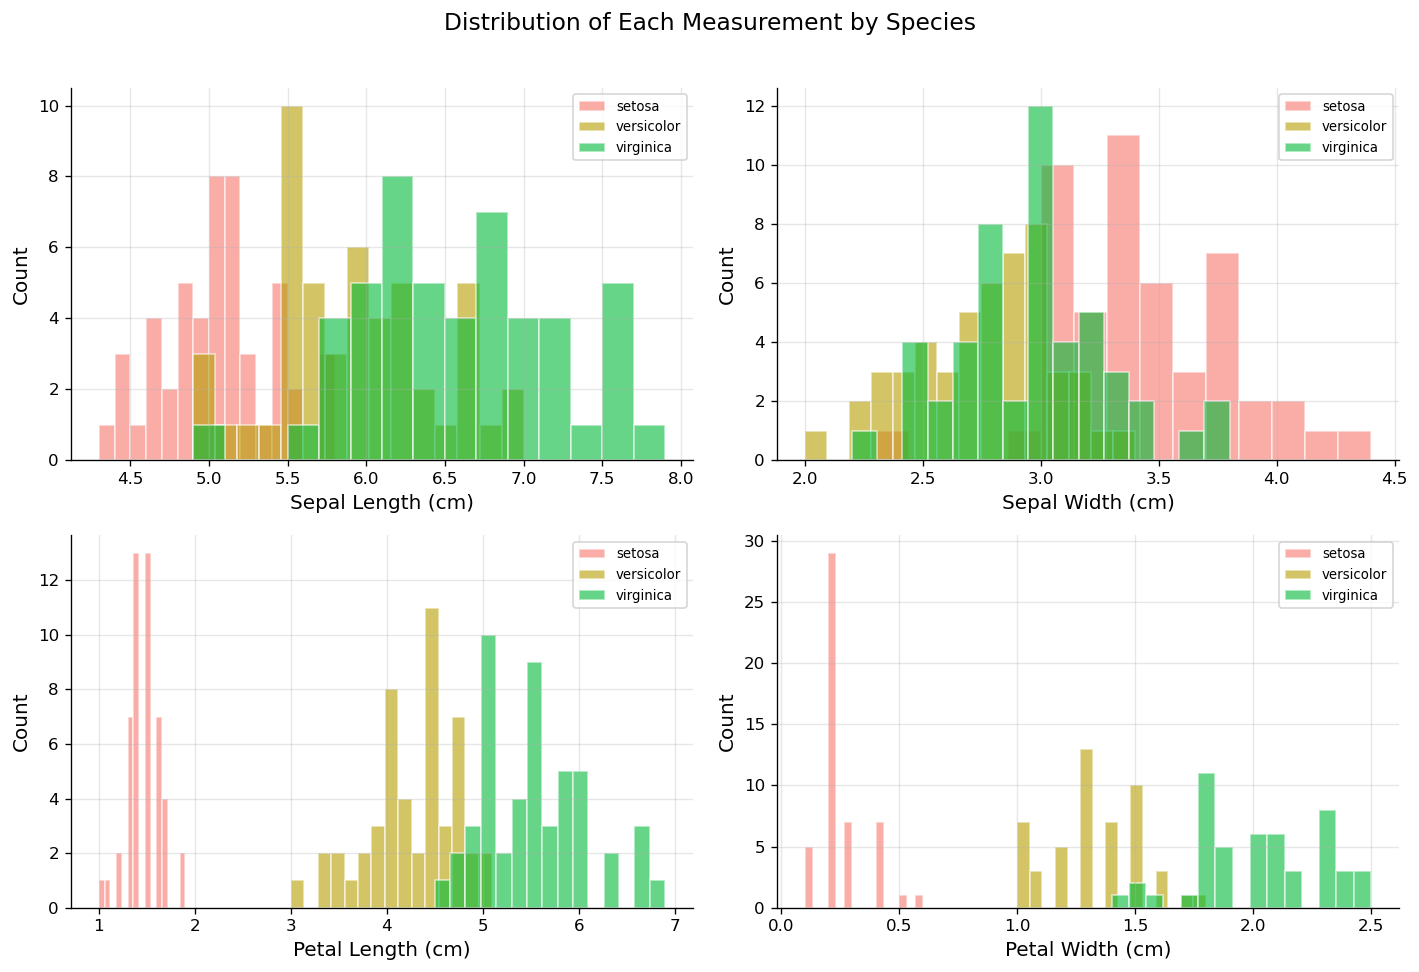

In [5]:
# Histograms of all numeric columns, coloured by species
numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_cols):
    for species in df["species"].unique():
        subset = df[df["species"] == species][col]
        ax.hist(subset, bins=15, alpha=0.6, label=species, edgecolor="white")
    ax.set_xlabel(col.replace("_", " ").title() + " (cm)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Each Measurement by Species", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The petal measurements separate the species much better than the sepal measurements. Setosa (small petals) is clearly distinct; Versicolor and Virginica overlap in sepals but less so in petals. This kind of observation guides later modelling decisions.

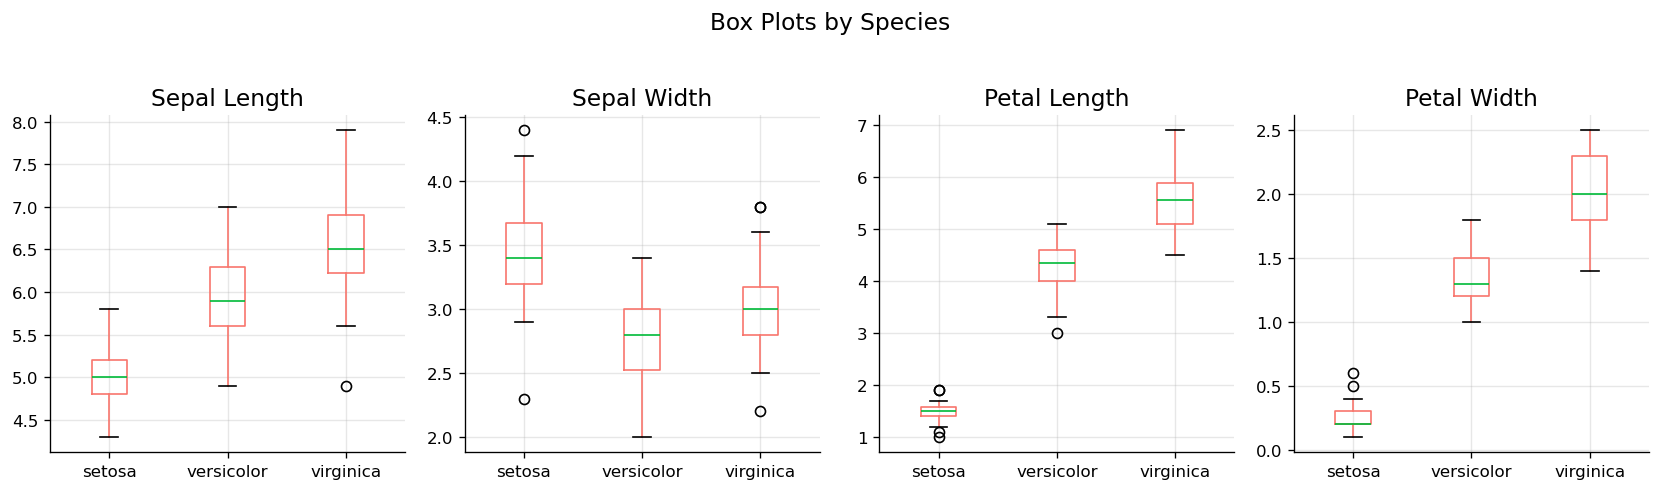

In [6]:
# Box plots — compact comparison across groups
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    df.boxplot(column=col, by="species", ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("")

plt.suptitle("Box Plots by Species", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Bivariate Exploration: Relationships Between Variables

### Scatter plots

The simplest way to see if two variables are related: plot one against the other.

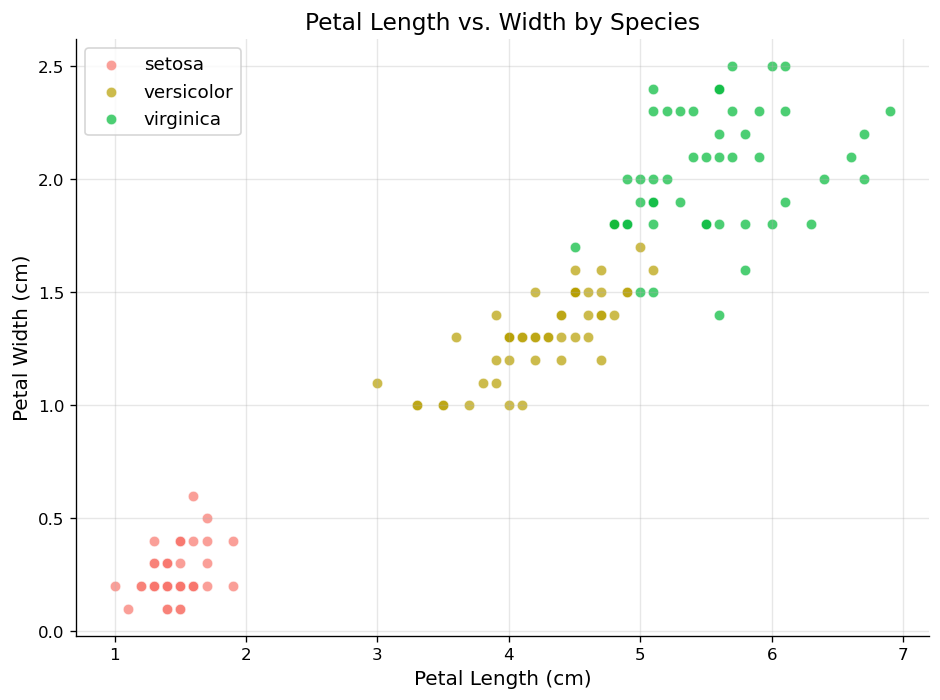

In [ ]:
# Scatter: petal length vs. petal width (the strongest relationship)
fig, ax = plt.subplots(figsize=(8, 6))

for species in df["species"].unique():
    subset = df[df["species"] == species]
    ax.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=species,
        alpha=0.7,
        s=40,
        edgecolors="white",
        linewidth=0.5,
    )

ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Petal Width (cm)")
ax.set_title("Petal Length vs. Width by Species")
ax.legend()
plt.tight_layout()
plt.show()

Strong positive linear relationship within and across species. Setosa forms a separate cluster. This is the kind of pattern that makes classification easy — and the kind of structure that summary statistics alone would miss.

### Pair plot: all pairs at once

With 4 numeric variables, there are $\binom{4}{2} = 6$ pairs. A **pair plot** (or scatter matrix) shows them all, with distributions on the diagonal.

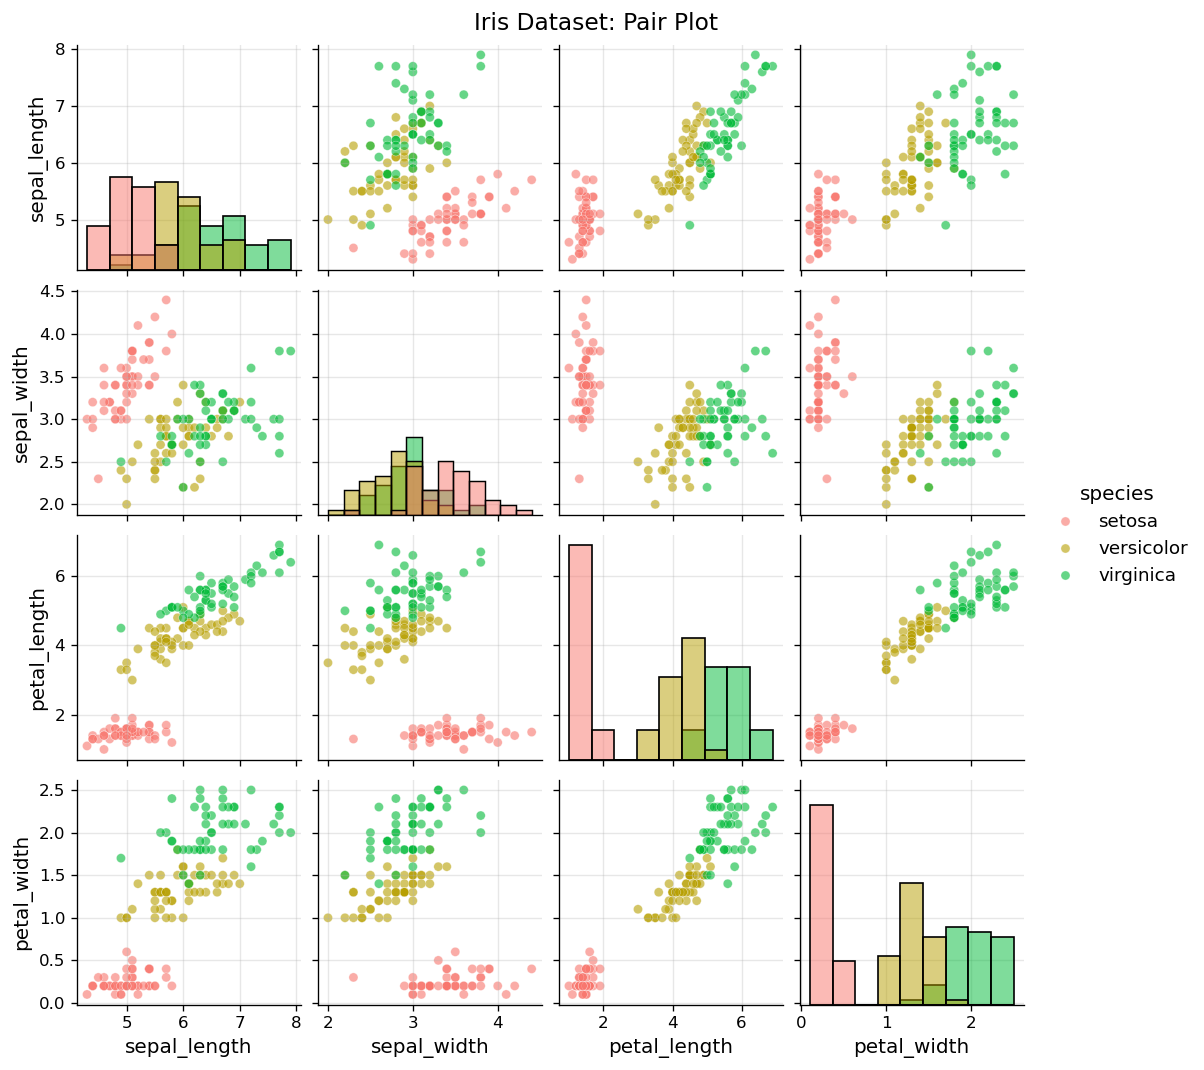

In [ ]:
# Pair plot — the cornerstone of multivariate EDA
g = sns.pairplot(
    df,
    hue="species",
    diag_kind="hist",
    height=2.2,
    plot_kws={"alpha": 0.6, "s": 30, "edgecolor": "white", "linewidth": 0.3},
)
g.figure.suptitle("Iris Dataset: Pair Plot", y=1.01, fontsize=14)
plt.show()

The pair plot gives a complete picture of the data at a glance. Each off-diagonal cell is a scatter plot of two variables; the diagonal shows each variable's distribution. Colour distinguishes species.

---

## 5. Correlation

The **Pearson correlation coefficient** quantifies the strength of the *linear* relationship between two variables:

$$r_{xy} = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$$

- $r = +1$: perfect positive linear relationship
- $r = 0$: no *linear* relationship (but there could be a nonlinear one!)
- $r = -1$: perfect negative linear relationship

**Caution:** Correlation measures *linear* association only. It misses curves, clusters, and other patterns. And **correlation does not imply causation** — two variables can be correlated because they share a common cause.

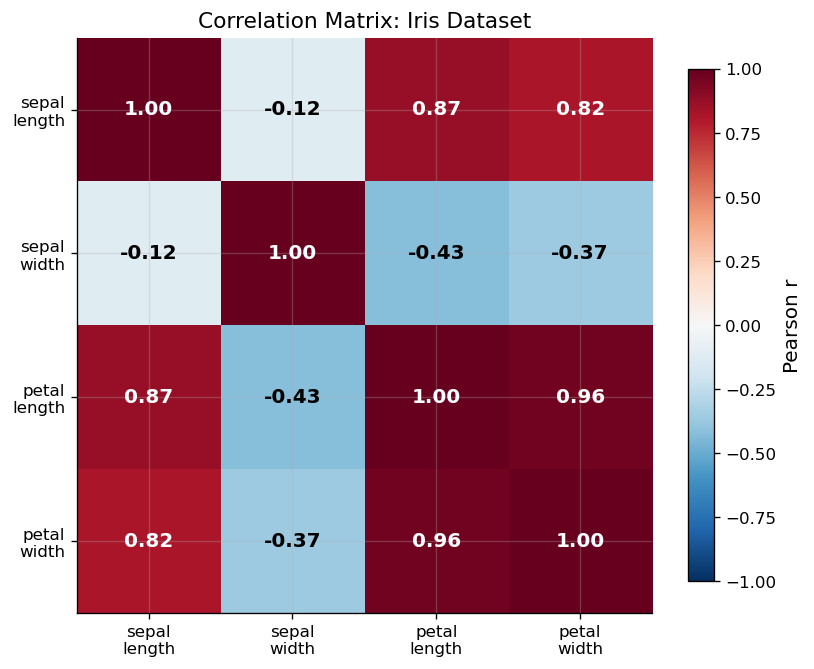

In [ ]:
# Correlation matrix + heatmap
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels([c.replace("_", "\n") for c in numeric_cols], fontsize=10)
ax.set_yticklabels([c.replace("_", "\n") for c in numeric_cols], fontsize=10)

# Annotate with values
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="white" if abs(corr.iloc[i, j]) > 0.5 else "black",
        )

fig.colorbar(im, label="Pearson r", shrink=0.8)
ax.set_title("Correlation Matrix: Iris Dataset", fontsize=13)
plt.tight_layout()
plt.show()

Petal length and petal width are highly correlated ($r = 0.96$). Sepal width has weak or negative correlations with petal measurements — visible in the pair plot as the cloud that doesn't follow a clear linear trend.

---

## 6. The EDA Workflow in Practice

A systematic EDA checklist:

| Step             | Question                             | Tools                                |
|------------------|--------------------------------------|--------------------------------------|
| 1. Overview      | How many rows/columns? Types?        | `df.shape`, `df.dtypes`, `df.head()` |
| 2. Missing data  | Any NaN/null values?                 | `df.isnull().sum()`                  |
| 3. Summary stats | Centre, spread, shape?               | `df.describe()`                      |
| 4. Distributions | What does each variable look like?   | Histograms, box plots                |
| 5. Relationships | Which variables are related?         | Scatter plots, pair plots            |
| 6. Correlation   | How strong are linear relationships? | Correlation matrix, heatmap          |
| 7. Groups        | Does structure differ by category?   | Colour-coded plots, groupby          |
| 8. Anomalies     | Outliers? Impossible values?         | Box plots, scatter plots             |

This is not a rigid recipe — it's a starting point. The specifics depend on the data and the questions you're trying to answer.

---

## Exercises

**Exercise 2.1 (Full EDA).** Load the `tips` dataset (`sns.load_dataset('tips')`). Perform a full EDA following the checklist above. What determines the tip amount?

**Exercise 2.2 (Correlation vs. causation).** Generate two independent random variables $X, Z \sim \mathcal{N}(0,1)$ (10,000 samples each). Compute $Y = X + Z$. Now compute $\text{corr}(X, Y)$ and $\text{corr}(Z, Y)$. Both are correlated with $Y$ but not with each other. Explain.

**Exercise 2.3 (Nonlinear relationship).** Generate $X \sim \text{Uniform}(-3, 3)$ and $Y = X^2 + \text{noise}$. Compute $r_{xy}$. Is it close to zero? Now plot the scatter. What does this tell you about the limitation of Pearson correlation?

**Exercise 2.4 (Grouped statistics).** Using the Iris dataset, compute the mean and standard deviation of each measurement *within* each species. Which measurement has the smallest within-species variance relative to the between-species spread? (This is the best discriminator — a preview of ANOVA in Module 06.)

**Exercise 2.5 (Real data).** Find a dataset that interests you (Kaggle, UCI ML Repository, or government open data). Load it, clean it, and perform a full EDA. Write a short paragraph summarising your findings.

---

## Key Takeaways

1. **EDA before modelling** — always understand your data visually and numerically before fitting any model.
2. **Histograms** show distributions; **box plots** compare groups; **scatter plots** reveal relationships; **pair plots** give the full picture.
3. **Correlation** measures linear association only. $r \approx 0$ doesn't mean "no relationship", and $r \approx 1$ doesn't mean "causes".
4. **Pandas** (`.describe()`, `.corr()`, `.groupby()`) and **Seaborn** (`pairplot`, `boxplot`, `heatmap`) are the workhorses of EDA in Python.
5. The EDA checklist: overview → missing data → summary stats → distributions → relationships → correlation → groups → anomalies.

**This completes Module 03: Descriptive Statistics.** You can now describe and explore any dataset.

**Next:** [Module 04 — Estimation](../04_estimation/01_point_estimation.ipynb) — How to *estimate* population parameters from sample data, and how to quantify the uncertainty in those estimates.